In [ ]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("alisadeghiaghili/soil-measure")

print("Path to dataset files:", path)
file_name = os.listdir(path)[0]
print("File name:", file_name)

100%|██████████| 23.9k/23.9k [00:00<00:00, 23.6MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/alisadeghiaghili/soil-measure/versions/1
File name: soil_measures.csv


In [ ]:
import pandas as pd
df = pd.read_csv(os.path.join(path, file_name))
df.tail(5)

,N,P,K,ph,crop
2195,107,34,32,6.780064,coffee
2196,99,15,27,6.086922,coffee
2197,118,33,30,6.362608,coffee
2198,117,32,34,6.758793,coffee
2199,104,18,30,6.779833,coffee


In [ ]:
# N, P, K -> (0 - 30) Low (30 - 70) medium
# pH < 5.5 (acidic) (6.0 - 7.5) optimal >8.0 alkaline suited for cottons

In [ ]:
df.groupby('crop')['N'].max().sort_values(ascending = False)


,N
crop,
cotton,140
banana,120
muskmelon,120
watermelon,120
coffee,120
jute,100
maize,100
rice,99
papaya,70


In [ ]:
# Dataset properties
print(df.shape)
print(df.info())
print(df.describe())

(2200, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   N       2200 non-null   int64  
 1   P       2200 non-null   int64  
 2   K       2200 non-null   int64  
 3   ph      2200 non-null   float64
 4   crop    2200 non-null   object 
dtypes: float64(1), int64(3), object(1)
memory usage: 86.1+ KB
None
                 N            P            K           ph
count  2200.000000  2200.000000  2200.000000  2200.000000
mean     50.551818    53.362727    48.149091     6.469480
std      36.917334    32.985883    50.647931     0.773938
min       0.000000     5.000000     5.000000     3.504752
25%      21.000000    28.000000    20.000000     5.971693
50%      37.000000    51.000000    32.000000     6.425045
75%      84.250000    68.000000    49.000000     6.923643
max     140.000000   145.000000   205.000000     9.935091


In [ ]:
crop_name = 'rice'
rice_df = df.query(f"crop == '{crop_name}'")
N_value = rice_df['N'].min()
P_value = rice_df['P'].min()
K_value = rice_df['K'].min()

nutrients = {
    'N': N_value,
    'P': P_value,
    'K': K_value
}

# dominant_nutrient = max(nutrients, key = nutrients.get)

# print(f"The dominant nutrient in {crop_name} is {dominant_nutrient} with avg of {nutrients[dominant_nutrient]}")

# avg_ph = rice_df['ph'].mean()
print(f"The average pH value for {crop_name} is {avg_ph}")


The average pH value for rice is 6.425470922139999


In [ ]:
df['crop'].unique()

array(['rice', 'maize', 'chickpea', 'kidneybeans', 'pigeonpeas',
       'mothbeans', 'mungbean', 'blackgram', 'lentil', 'pomegranate',
       'banana', 'mango', 'grapes', 'watermelon', 'muskmelon', 'apple',
       'orange', 'papaya', 'coconut', 'cotton', 'jute', 'coffee'],
      dtype=object)

In [ ]:
#checking for inconsistencies
df.isnull().sum()

,0
N,0
P,0
K,0
ph,0
crop,0


In [ ]:
#Value counts
df['crop'].value_counts()

,count
crop,
rice,100
maize,100
chickpea,100
kidneybeans,100
pigeonpeas,100
mothbeans,100
mungbean,100
blackgram,100
lentil,100


In [ ]:
# Data Exploration
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
#Using a boxplot visualize the nutrient usage for each crops

def plot_nutrient_usage(data, column, color_palette):
  sns.set_style("whitegrid")
  plt.figure(figsize=(12, 6))

  ax = sns.boxplot(
      data = data,
      x = 'crop',
      y = column,
      palette = color_palette
  )

  sns.despine(offset = 10, trim = True)
  plt.title(f"Analysis of {column} Levels by Crops Type", fontsize = 16, fontweight = 'bold', pad = 20)
  plt.xlabel("Crop Type", fontsize = 14, fontweight = 'bold')
  plt.ylabel(f'{column} concentration', fontsize = 12)

  plt.xticks(rotation = 45, ha = 'right')
  ax.yaxis.grid(True, linestyle = '--', alpha = 0.7)

  plt.tight_layout()
  plt.show()


/tmp/ipython-input-740287985.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


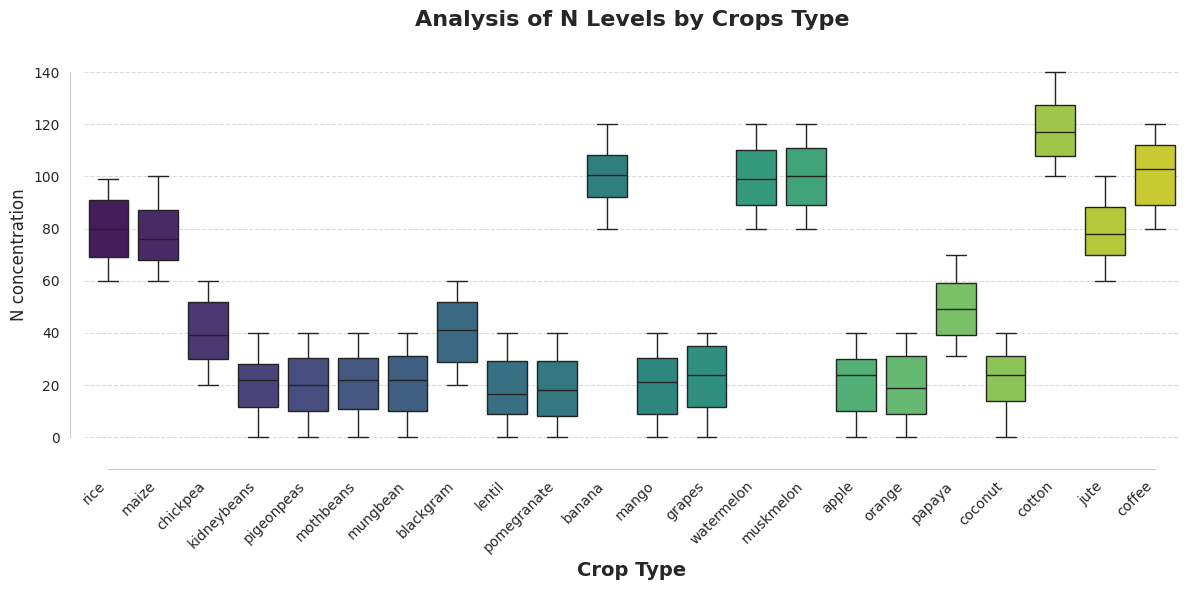

In [ ]:
plot_nutrient_usage(df, 'N', 'viridis')

/tmp/ipython-input-740287985.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


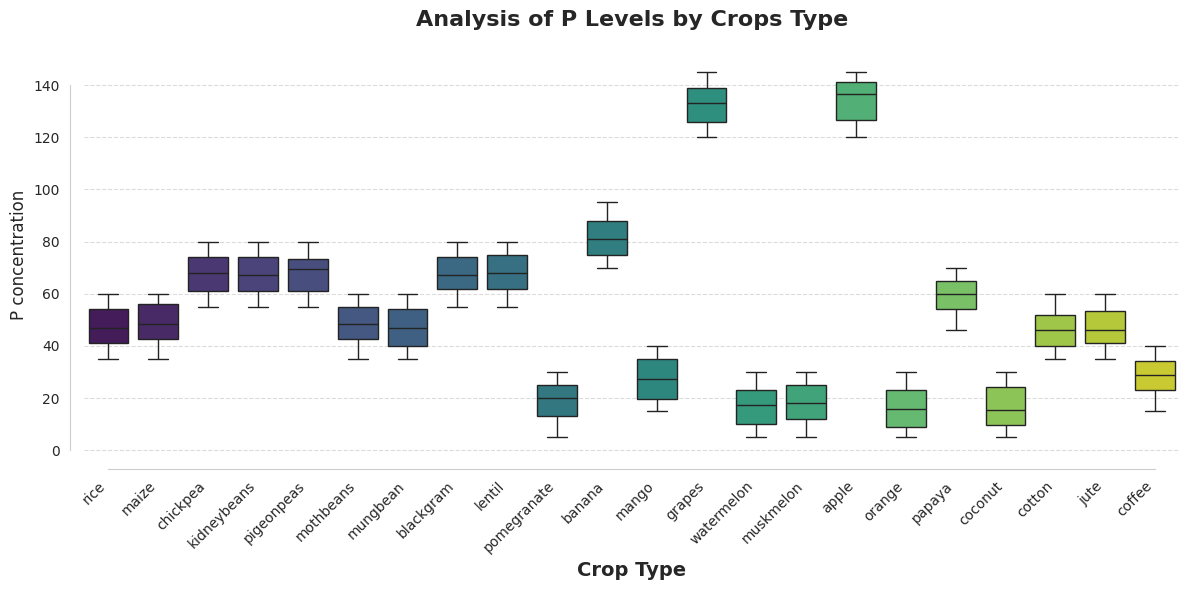

In [ ]:
plot_nutrient_usage(df, 'P', 'viridis')

/tmp/ipython-input-740287985.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


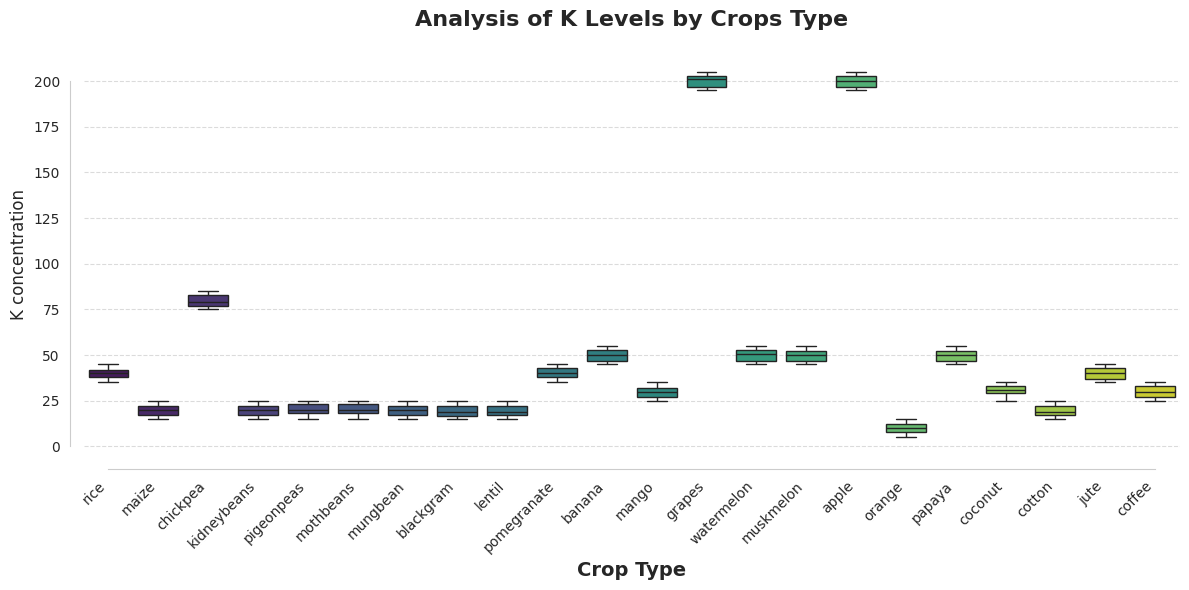

In [ ]:
plot_nutrient_usage(df, 'K', 'viridis')

/tmp/ipython-input-740287985.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


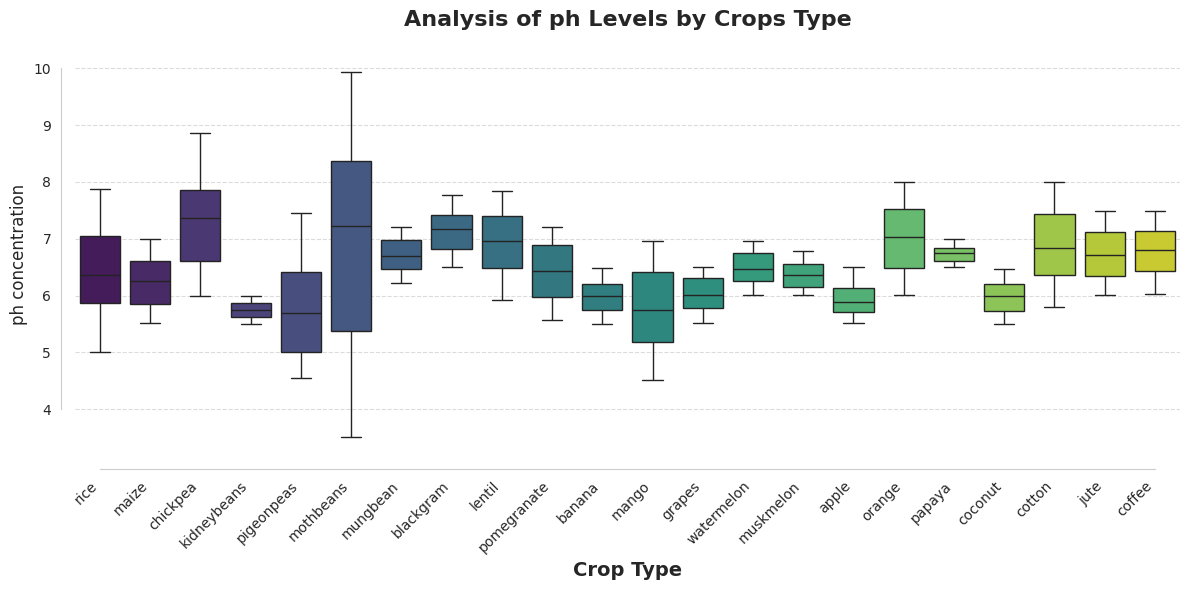

In [ ]:
plot_nutrient_usage(df, 'ph', 'viridis')

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.pipeline import Pipeline

X = df.drop('crop', axis = 1)
y = df['crop']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1760, 4) (440, 4) (1760,) (440,)


In [ ]:
discrete_features = X.dtypes == int
discrete_features

,0
N,True
P,True
K,True
ph,False


In [ ]:
encoder = LabelEncoder()
y_train = encoder.fit_transform(y_train)
y_test = encoder.transform(y_test)



In [ ]:
# Adding ratios

def add_ratios(X):
  X = X.copy()
  X['N_P_ratio'] = X['N'] / (X['P'] + 1e-5) # adding epsilon to avoid division by zero
  X['P_K_ratio'] = X['P'] / (X['K'] + 1e-5)
  X['N_K_ratio'] = X['N'] / (X['K'] + 1e-5)
  return X

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

search_space = {
    'RandomForestClassifier':{
        'model': RandomForestClassifier(),
        'parameters':{
            'clf__n_estimators' : [100,200, 300, 500],
            'clf__max_depth' : [None, 10, 20, 30],
            'clf__min_samples_split' :[2, 5, 10],
            'clf__criterion' : ['gini', 'entropy']
        }
    },

    'DecisionTreeClassifier':{
        'model': DecisionTreeClassifier(),
        'parameters':{
            'clf__criterion' : ['gini', 'entropy'],
            'clf__max_depth' : [None, 5, 10, 15, 20],
            'clf__min_samples_leaf' : [1, 2, 4]
        }
    },

    'Logistic Regression':{
        'model': LogisticRegression(),
        'parameters':{
            'clf__C' :[0.1, 1, 10, 100],
            'clf__solver' :['lbfgs', 'liblinear'],
            'clf__max_iter': [100, 200, 500]
        }
    },

    'XGBClassifier' : {
        'model' : XGBClassifier(),
        'parameters' : {
            'clf__n_estimators' : [100, 200, 500],
            'clf__learning_rate' : [0.01, 0.1, 0.2],
            'clf__max_depth' : [3, 5, 7],
            'clf__subsample' : [0.8, 1.0]
        }
    }

        }



In [ ]:
from sklearn.model_selection import RandomizedSearchCV

def tune_models(X, y, search_space, include_feat_eng = True):
  results = []
  best_overall_score = 0
  best_overall_pipeline = None

  for model_name, model_info in search_space.items():

    pipe = Pipeline([
        ('feat_eng', FunctionTransformer(add_ratios) if include_feat_eng else 'passthrough'),
        ('scaler', StandardScaler()),
        ('clf', model_info['model'])
    ])

    random_search = RandomizedSearchCV(
        estimator = pipe,
        param_distributions = model_info['parameters'],
        cv = 5,
        n_iter = 10,
        random_state = 42,
        n_jobs = -1

    )

    random_search.fit(X_train, y_train)
    results.append({
        'model': model_name,
        'best_params' : random_search.best_params_,
        'best_score' : random_search.best_score_
    })

    if random_search.best_score_ > best_overall_score:
      best_overall_score = random_search.best_score_
      best_overall_pipeline = random_search.best_estimator_
  return results, best_overall_pipeline, best_overall_score

In [ ]:
results, best_overall_pipeline, best_overall_score = tune_models(X_train, y_train, search_space)

In [ ]:
result_df = pd.DataFrame(results)
result_df.sort_values(by = 'best_score', ascending = False)

,model,best_params,best_score
0,RandomForestClassifier,"{'clf__n_estimators': 100, 'clf__min_samples_s...",0.786932
3,XGBClassifier,"{'clf__subsample': 1.0, 'clf__n_estimators': 1...",0.785795
1,DecisionTreeClassifier,"{'clf__min_samples_leaf': 4, 'clf__max_depth':...",0.773295
2,Logistic Regression,"{'clf__solver': 'lbfgs', 'clf__max_iter': 500,...",0.705114


In [ ]:
y_pred = best_overall_pipeline.predict(X_test)

In [ ]:
# Saving the model & encoder
import joblib

joblib.dump(best_overall_pipeline, 'crop_prediction_model.joblib')
joblib.dump(encoder, 'encoder.joblib')
print("Model Successfully saved as crop_prediction_model.joblib")

Model Successfully saved as crop_prediction_model.joblib


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plotting
plt.figure(figsize=(20, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=encoder.classes_)
disp.plot(cmap='Blues', xticks_rotation='vertical')
ax = plt.gca()
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.title('Confusion Matrix: Predicted vs. Actual Crops', fontsize=16)
plt.show()

In [ ]:
# identifying the most confused pairs

def get_top_confusion(cm, labels, n = 3):

  cm_df = pd.DataFrame(cm, index = labels, columns = labels)

  # Reshaping to the long format
  confusion_list = cm_df.stack().reset_index()
  confusion_list.columns = ['Actual', 'Predicted', 'Count']

  # Filtering correct predictions
  errors = confusion_list[confusion_list['Actual'] != confusion_list['Predicted']]

  # Sort by count to find the biggest mistake
  top_errors = errors.sort_values(by = 'Count', ascending = False).head(n)
  return top_errors

top_3_errors = get_top_confusion(cm, encoder.classes_)
print(confusion_list)



In [ ]:
def plot_confusion_matrix_error_ratio(df, title):
  df['Mistake'] = df['Actual'] + " misidentified as " + df['Predicted']
  plt.figure(figsize = (10, 6))

  sns.barplot(
      data = df,
      x = 'Count',
      y = 'Mistake',
      palette = 'Oranges_r'
  )
  plt.title(title, fontsize=15, fontweight='bold')
  plt.xlabel('Number of Mistakes', fontsize=12)
  plt.ylabel('Type of Confusion', fontsize=12)
  plt.show()

In [ ]:
# model with some features engineering (Ratios)
plot_confusion_matrix_error_ratio(top_3_errors, 'Top 3 Mistakes (Ratios)')

In [ ]:
#saved models

saved_model_top_confusion = get_top_confusion(confusion_matrix(y_test, saved_model_prediction), loaded_encoder.classes_)
plot_confusion_matrix_error_ratio(saved_model_top_confusion, 'Top 3 Mistakes (Saved Model)')

In [ ]:
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred, target_names = encoder.classes_, output_dict= True)
report_df = pd.DataFrame(report).transpose()

plt.figure(figsize = (15, 10))
sns.heatmap(report_df, annot = True, cmap = 'Reds', fmt = '.2f')
plt.title('Classification Report', fontsize = 16)
plt.show()


In [ ]:
def plot_feature_importance(pipeline, feature_names):
  model = pipeline.named_steps['clf']

  importances = model.feature_importances_

  feat_imp_df = pd.DataFrame({
      'Feature': feature_names,
      'Importance': importances
  }).sort_values(by = 'Importance', ascending = False)

  plt.figure(figsize = (10, 6))
  sns.barplot(
      data = feat_imp_df,
      x = 'Importance',
      y = 'Feature',
      palette = 'magma'
  )
  plt.title('Feature Importance', fontsize = 16)
  plt.xlabel('Importance', fontsize = 12)
  plt.ylabel('Feature', fontsize = 12)
  plt.grid(axis = 'x', linestyle = '--', alpha = 0.7)
  plt.tight_layout()
  plt.show()


/tmp/ipython-input-2553989616.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


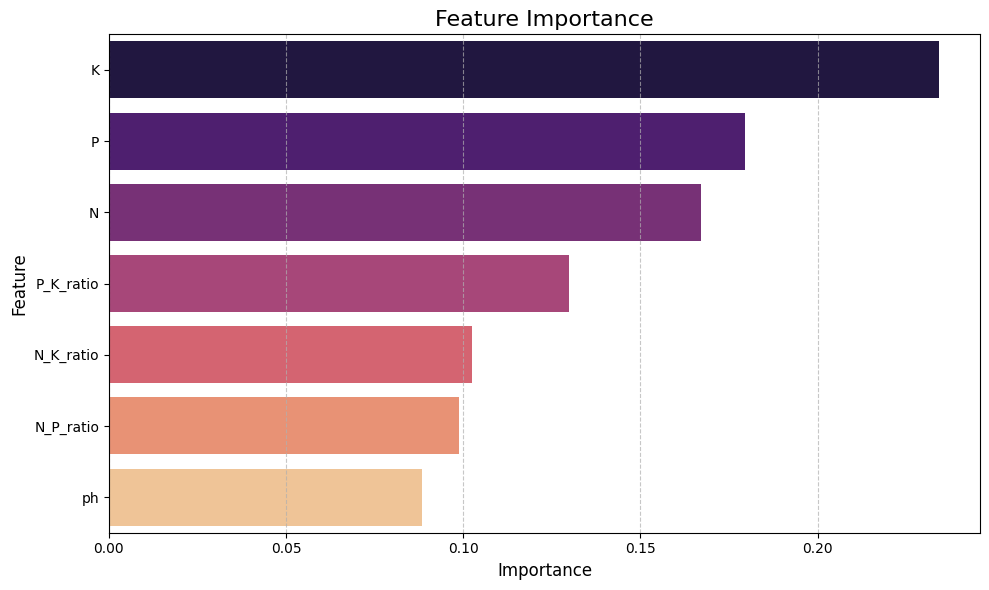

In [ ]:
plot_feature_importance(best_overall_pipeline,add_ratios(X).columns)